In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

import statsmodels.api as sm

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'simple_linear_regression_dataset.csv')
print(df.head())
type(df)

   Height (Inches)  Weight (Pounds)
0            65.78           112.99
1            71.52           136.49
2            69.40           153.03
3            68.22           142.34
4            67.79           144.30


pandas.core.frame.DataFrame

In [3]:
df.columns

Index([' Height (Inches)', ' Weight (Pounds)'], dtype='object')

In [4]:
df.rename(columns = {' Height (Inches)' : 'Height', ' Weight (Pounds)' : 'Weight'}, inplace = True)

Text(0, 0.5, 'Height')

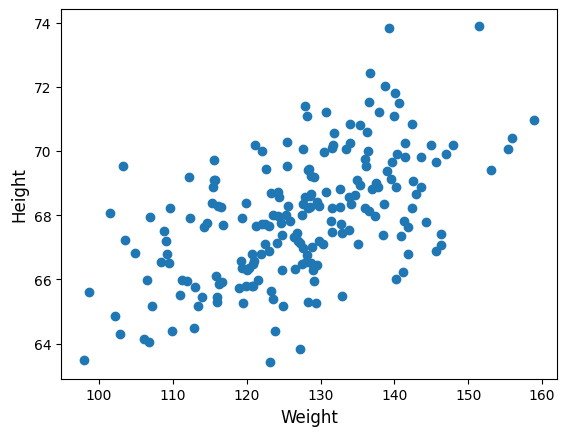

In [5]:
plt.scatter(df['Weight'], df['Height'])

plt.xlabel('Weight', fontsize = 12)
plt.ylabel('Height', fontsize = 12)

In [6]:
df.corr()

,Height,Weight
Height,1.000000,0.556865
Weight,0.556865,1.000000


In [7]:
X = df[['Weight']] # independent feature - should be Dataframe or 2D array
y = df['Height'] # dependent feature - should be seies or 1D array

In [8]:
print(X.shape)
print(y.shape)

(200, 1)
(200,)


In [9]:
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [10]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)

(160, 1)
(160,)


In [11]:
# Before Standardizatino for features
pd.DataFrame(df[['Weight', 'Height']])

,Weight,Height
0,112.99,65.78
1,136.49,71.52
2,153.03,69.40
3,142.34,68.22
4,144.30,67.79
...,...,...
195,120.84,65.80
196,115.78,66.11
197,128.30,68.24
198,127.47,68.02


In [29]:
# After Standardization for features

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

# fit_transform is a method in scikit-learn that performs two actions in one step:

# Step 1 'fit':
#   The fit part calculates the necessary statistics (like mean and standard deviation) 

# Step 2 'transform':
#   The transform part applies the scaling transformation to the data:
#   Subtract the mean from each feature value and Divide by the standard deviation.

array([[-3.99728792e-01],
       [ 9.21665492e-02],
       [ 3.51730700e-01],
       [ 1.24531220e+00],
       [ 8.96134592e-02],
       [-5.42701832e-01],
       [-1.13416768e+00],
       [-2.70372232e-01],
       [ 3.08923891e-02],
       [ 1.16361332e+00],
       [-4.40578232e-01],
       [-6.55037792e-01],
       [-3.33348452e-01],
       [-1.50691882e+00],
       [ 7.52565831e-01],
       [-2.07455584e+00],
       [ 7.65331281e-01],
       [ 7.85500692e-02],
       [-2.18459401e-01],
       [-6.11635262e-01],
       [-1.35713754e+00],
       [-3.50369052e-01],
       [-5.50361102e-01],
       [-1.36760521e-01],
       [ 1.30462899e-01],
       [ 8.24052351e-01],
       [ 1.05978766e+00],
       [-2.19114695e+00],
       [ 7.94266301e-01],
       [-9.00985463e-01],
       [-7.54863612e-02],
       [-6.72909423e-01],
       [ 1.00702380e+00],
       [-2.00587771e-01],
       [-9.59706533e-01],
       [-1.30352265e+00],
       [ 1.29382091e+00],
       [ 2.70882850e-01],
       [-2.1

In [13]:
# Apply Simple Linear Regression
model_1 = LinearRegression(n_jobs = -1)
model_1.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [14]:
# Access parameters
print("Coefficients (weights):", model_1.coef_)
print("Intercept:", model_1.intercept_)

Coefficients (weights): [1.15072844]
Intercept: 67.80575


In [15]:
y_train_pred = model_1.predict(X_train)
y_test_pred  = model_1.predict(X_test)

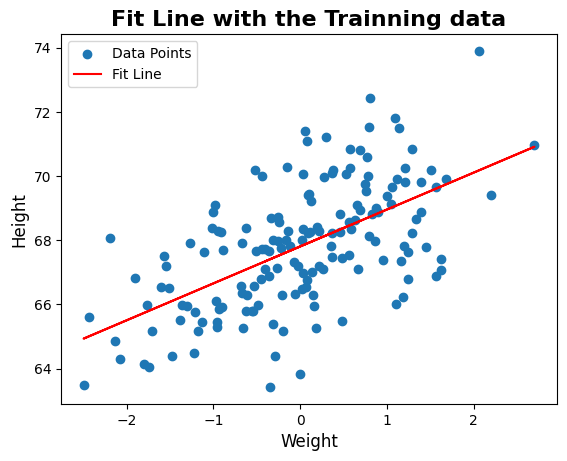

In [16]:
# Plot the Best Fit Line for Trainning data
plt.scatter(X_train, y_train, label = 'Data Points')
plt.plot(X_train, y_train_pred, color = 'red', label = 'Fit Line')

plt.title('Fit Line with the Trainning data', fontsize = 16, fontweight = 'bold')
plt.xlabel('Weight', fontsize = 12)
plt.ylabel('Height', fontsize = 12)

plt.legend(loc = 'best')
plt.show()

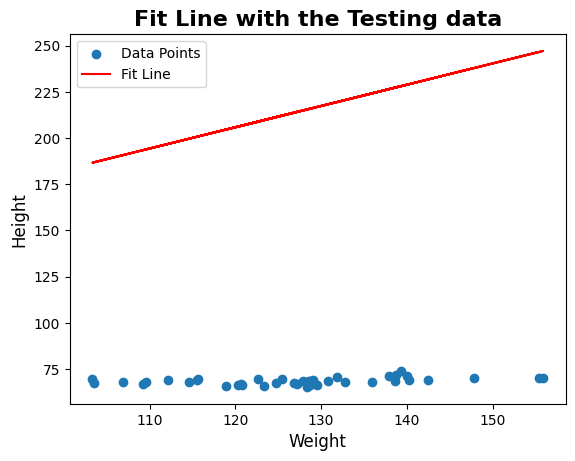

In [17]:
# Plot the Best Fit Line for Testing data
plt.scatter(X_test, y_test, label = 'Data Points')
plt.plot(X_test, y_test_pred, color = 'red', label = 'Fit Line')

plt.title('Fit Line with the Testing data', fontsize = 16, fontweight = 'bold')
plt.xlabel('Weight', fontsize = 12)
plt.ylabel('Height', fontsize = 12)

plt.legend(loc = 'best')
plt.show()

In [18]:
# Model Performance with MSE, MAE, RMSE

MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_test  = mean_squared_error(y_test, y_test_pred)

print('MSE with Trainnig data: ', MSE_train)
print('MSE with Testing data : ', MSE_test)
print('=' * 45)
# ========================================================

MAE_train = mean_absolute_error(y_train, y_train_pred)
MAE_test  = mean_absolute_error(y_test, y_test_pred)

print('MAE with Trainnig data: ', MAE_train)
print('MAE with Testing data : ', MAE_test)
print('=' * 45)
# ========================================================

RMAE_train = root_mean_squared_error(y_train, y_train_pred)
RMAE_test  = root_mean_squared_error(y_test, y_test_pred)

print('RMAE with Trainnig data: ', RMAE_train)
print('RMAE with Testing data : ', RMAE_test)
print('=' * 45)
# ========================================================



MSE with Trainnig data:  2.437859744473756
MSE with Testing data :  21419.564356052466
MAE with Trainnig data:  1.2539302122766365
MAE with Testing data :  145.7004505025629
RMAE with Trainnig data:  1.561364705785857
RMAE with Testing data :  146.35424269918678


In [19]:
# Model Performance with R2 Score and adjusted R2 Score

# R2 Score
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print('R2 Score with Tranning data: ', r2_train)
print('R2 Score with Testing data: ', r2_test)
print('=' * 59)
# =======================================================================================

# Adjusted R2 Score
p = X_train.shape[1]

adjusted_r2_train = 1 - ((1 - r2_train) * (len(y_train) - 1) / (len(y_train) - p - 1))
adjusted_r2_test = 1 - ((1 - r2_test) * (len(y_test) - 1) / (len(y_test) - p - 1))

print('Adjusted R2 Score with Tranning data: ', adjusted_r2_train)
print('Adjusted R2 Score with Testing data: ', adjusted_r2_test)

R2 Score with Tranning data:  0.3519838866563765
R2 Score with Testing data:  -6553.8176459930055
Adjusted R2 Score with Tranning data:  0.3478825188504042
Adjusted R2 Score with Testing data:  -6726.312847203348


In [20]:
# OLS: Ordinary Least Square

# Add a constant (intercept term) to the independent variable matrix X
X = sm.add_constant(X)

# Fit the OLS model
model_2 = sm.OLS(y, X).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     89.00
Date:                Thu, 26 Dec 2024   Prob (F-statistic):           1.10e-17
Time:                        13:54:31   Log-Likelihood:                -378.74
No. Observations:                 200   AIC:                             761.5
Df Residuals:                     198   BIC:                             768.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.4569      1.224     46.140      0.0

In [30]:
model_1.predict([[75]])

array([154.11038301])